In [ ]:
import pandas as pd
import glob
import os
import re

# Display names for multi-word country slugs
COUNTRY_DISPLAY = {
    'albania'               : 'Albania',
    'bosnia_and_herzegovina': 'Bosnia & Herzegovina',
    'kosovo'                : 'Kosovo',
    'montenegro'            : 'Montenegro',
    'north_macedonia'       : 'North Macedonia',
    'serbia'                : 'Serbia',
    'turkey'                : 'Turkey',
}

cwd         = os.getcwd()
folder_path = os.path.abspath(os.path.join(cwd, "..", "scraped"))
files       = glob.glob(os.path.join(folder_path, "*_corpus.txt"))

print(f"📍 Notebook is in: {cwd}")
print(f"📂 Looking for data in: {folder_path}")
print(f"📊 Found {len(files)} files.")

data = []
for f in files:
    filename = os.path.basename(f)          # e.g. north_macedonia_2023_corpus.txt
    parts    = filename.split("_")

    # Year is the first 4-digit token; everything before it is the country slug
    year_idx = next((i for i, p in enumerate(parts) if re.fullmatch(r'\d{4}', p)), None)
    if year_idx is None:
        print(f"  ⚠  Could not parse year from {filename}, skipping.")
        continue

    country_slug = "_".join(parts[:year_idx])   # handles multi-word names
    year         = parts[year_idx]

    with open(f, 'r', encoding='utf-8') as fh:
        full_text = fh.read()

    segments = re.split(r'\s*\*\s*\*\s*\*\s*', full_text)
    if len(segments) >= 2:
        data.append({"country": country_slug, "year": year, "section": "1.1_Context", "text": segments[0].strip()})
        data.append({"country": country_slug, "year": year, "section": "1.2_Summary", "text": segments[1].strip()})
    else:
        data.append({"country": country_slug, "year": year, "section": "Full_Summary", "text": full_text.strip()})

df = pd.DataFrame(data)
df['word_count'] = df['text'].apply(lambda x: len(x.split()))

# Friendly display label (used in plots)
df['country_label'] = df['country'].map(COUNTRY_DISPLAY).fillna(df['country'].str.replace('_', ' ').str.title())

print("✅ Dataframe loaded.")
print(f"   Countries: {sorted(df['country'].unique())}")
display(df.sort_values(['country', 'year']).head(14))

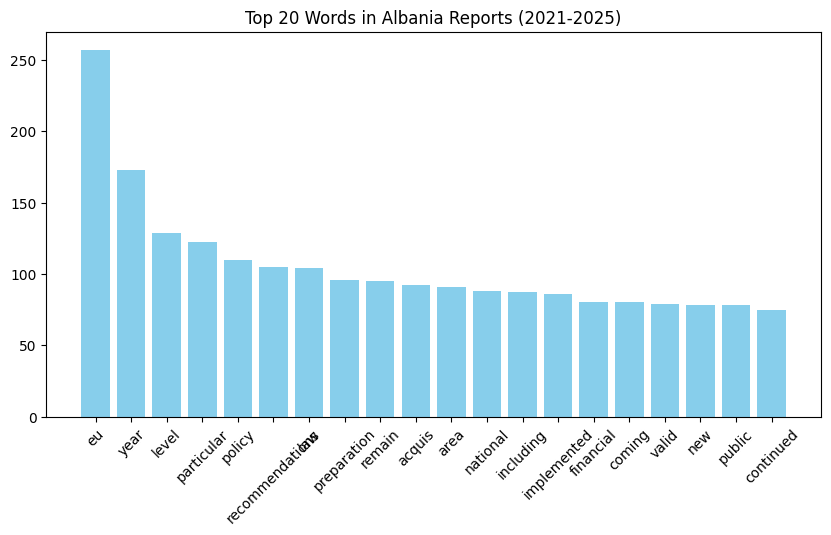

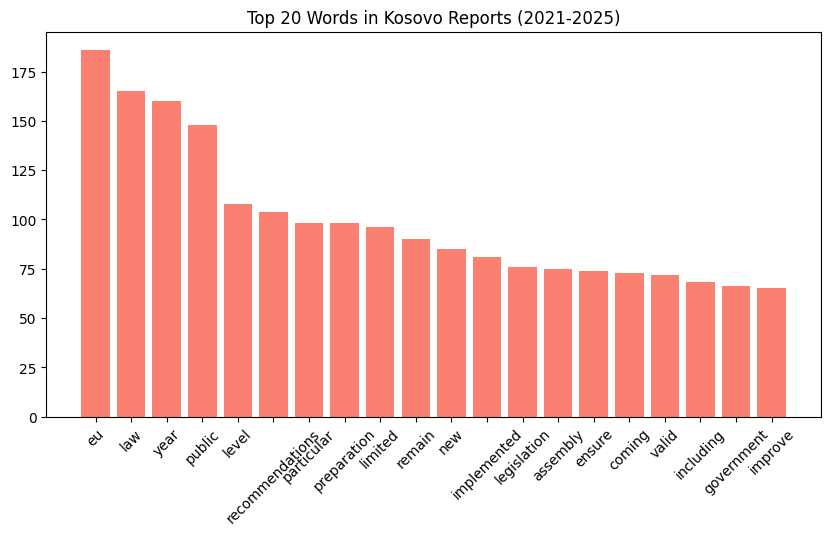

In [5]:
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction import text 

# 1. Define custom stopwords to filter out "EU-speak"
# These are words that appear in EVERY report and add zero value to LSA/LDA
extra_stop_words = [
    'albania', 'kosovo', 'commission', 'european', 'report', 'chapter', 
    'context', 'findings', 'introduction', 'implementation', 'progress', 
    'alignment', 'union', 'council', 'member', 'states', 'framework',
    'accession', 'negotiations', 'summary', 'follows', 'provided'
]
my_stop_words = text.ENGLISH_STOP_WORDS.union(extra_stop_words)

def plot_top_words(df, country_name, n=20):
    # Filter text for specific country
    country_text = df[df['country'].str.lower() == country_name.lower()]['text']
    
    # Vectorize to find word counts
    vec = CountVectorizer(stop_words=list(my_stop_words)).fit(country_text)
    bag_of_words = vec.transform(country_text)
    sum_words = bag_of_words.sum(axis=0) 
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key = lambda x: x[1], reverse=True)[:n]
    
    # Plotting
    words, counts = zip(*words_freq)
    plt.figure(figsize=(10, 5))
    plt.bar(words, counts, color='skyblue' if country_name == 'albania' else 'salmon')
    plt.title(f"Top {n} Words in {country_name.capitalize()} Reports (2021-2025)")
    plt.xticks(rotation=45)
    plt.show()

# Run the plots
plot_top_words(df, 'albania')
plot_top_words(df, 'kosovo')

In [ ]:
import re
import pandas as pd

def split_sections(row):
    text = row['text'].replace("∗", "*")

    # Primary split: *** separator (some PDFs use this between 1.1 and 1.2)
    parts = re.split(r'\s*\*\s*\*\s*\*\s*', text)

    # Fallback: split at the 1.2 header — period after "1.2" is optional
    # Handles: "1.2. SUMMARY", "1.2 MAIN FINDINGS", "1.2  ", "1.2 "
    if len(parts) < 2:
        parts = re.split(r'(?=1\.2\.?\s)', text, flags=re.IGNORECASE)

    base = {"country": row['country'], "year": row['year'],
            "country_label": row['country_label']}
    if len(parts) >= 2:
        return [
            {**base, "section": "1.1_Context", "text": parts[0].strip()},
            {**base, "section": "1.2_Summary", "text": parts[1].strip()},
        ]
    else:
        return [{**base, "section": "1.1_Context", "text": text.strip()}]

expanded_data = []
for _, row in df.iterrows():
    expanded_data.extend(split_sections(row))

df_final = pd.DataFrame(expanded_data)
df_final['word_count'] = df_final['text'].apply(lambda x: len(x.split()))

print(f"Original rows: {len(df)} | Split rows: {len(df_final)}")
print(f"Countries: {sorted(df_final['country'].unique())}")
display(df_final.sort_values(['country','year']).head(14))

# EDA — EU Enlargement Reports (Western Balkans + Turkey, 2021–2025)

Countries: Albania, Bosnia & Herzegovina, Kosovo, Montenegro, North Macedonia, Serbia, Turkey

Pipeline:
1. **Text Cleaning** — strip PDF artifacts, normalise whitespace
2. **Corpus Overview** — coverage, word counts, missing sections
3. **Vocabulary Richness** — TTR, unique tokens, hapax legomena
4. **TF-IDF Analysis** — distinctive terms per country and per year
5. **EU Progress Language** — keyword tracking over time
6. **N-gram Analysis** — top bigrams / trigrams
7. **Document Similarity** — cosine-similarity heatmap
8. **Pre-processing Export** — lemmatised, stopword-filtered corpus ready for LDA / LSA / EPU

## 1. Text Cleaning

Remove PDF header/footer boilerplate (page numbers, section headings repeated, footnote markers), collapse whitespace, and lower-case. We keep a `text_clean` column alongside the raw text so every subsequent step is reproducible.

In [ ]:
import re

def clean_text(text: str) -> str:
    """
    Strip PDF scraping artefacts from EU Enlargement report text.
    Returns lower-cased, normalised prose.
    """
    # Remove lone page numbers (lines that are just 1-3 digits)
    text = re.sub(r'^\s*\d{1,3}\s*$', '', text, flags=re.MULTILINE)

    # Remove footnote markers: superscript-style numbers after words  e.g. "report3 4"
    text = re.sub(r'(?<=\w)\d{1,2}(?=\s)', '', text)

    # Remove section header boilerplate that repeats in every doc
    boilerplate = [
        r'1\s*\.\s*INTRODUCTION[12]?\s*',
        r'1\s*\.1[\.]?\s*CONTEXT\s*',
        r'1\s*\.2[\.]?\s*(MAIN\s+FINDINGS\s+OF\s+THE\s+REPORT|SUMMARY\s+OF\s+THE\s+REPORT)\s*',
        r'CLUSTER\s+\d+\s*[:–\-]\s*',
    ]
    for pat in boilerplate:
        text = re.sub(pat, '', text, flags=re.IGNORECASE)

    # Collapse whitespace / newlines
    text = re.sub(r'\s+', ' ', text).strip()

    # Lower-case
    text = text.lower()

    return text


df_final['text_clean'] = df_final['text'].apply(clean_text)
df_final['word_count_clean'] = df_final['text_clean'].apply(lambda x: len(x.split()))

print("Sample cleaned text (albania 2024, 1.1_Context):\n")
sample = df_final.query("country=='albania' and year=='2024' and section=='1.1_Context'")['text_clean'].values[0]
print(sample[:600])
print("\n---\nClean word counts:")
display(df_final[['country','year','section','word_count','word_count_clean']])

## 2. Corpus Overview

Check coverage (which country × year × section combinations exist), flag missing entries, and summarise word-count statistics.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# Derive country/year lists dynamically from whatever is loaded
COUNTRIES = sorted(df_final['country'].unique())
YEARS     = sorted(df_final['year'].unique())
SECTIONS  = ['1.1_Context', '1.2_Summary']

# Auto colour palette — works for any number of countries
CMAP   = plt.cm.get_cmap('tab10', len(COUNTRIES))
COLORS = {c: CMAP(i) for i, c in enumerate(COUNTRIES)}

# ── Coverage check ─────────────────────────────────────────────────────────────
expected = pd.MultiIndex.from_product([COUNTRIES, YEARS, SECTIONS],
                                      names=['country','year','section'])
actual   = pd.MultiIndex.from_frame(df_final[['country','year','section']])
missing  = expected.difference(actual)

print(f"Countries  : {COUNTRIES}")
print(f"Years      : {YEARS}")
print(f"Expected   : {len(expected)} documents")
print(f"Found      : {len(actual)} documents")
if len(missing):
    print(f"\n⚠  Missing {len(missing)} entries:")
    for m in missing: print("  ", m)
else:
    print("✅ Full coverage — no missing combinations.")

# ── Summary statistics ─────────────────────────────────────────────────────────
stats = (df_final
         .groupby(['country','section'])['word_count_clean']
         .agg(['min','mean','median','max','std'])
         .round(1))
print("\nWord-count statistics (cleaned text):")
display(stats)

# ── Pivot: word count per document ────────────────────────────────────────────
pivot = df_final.pivot_table(
    index=['country','section'], columns='year',
    values='word_count_clean', aggfunc='first'
)
print("\nWord counts per document:")
display(pivot)

In [ ]:
# ── Word-count trend over time ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=False)

for ax, section in zip(axes, SECTIONS):
    for country in COUNTRIES:
        label = df_final.loc[df_final['country'] == country, 'country_label'].iloc[0]
        sub   = (df_final
                 .query("country==@country and section==@section")
                 .sort_values('year'))
        if sub.empty:
            continue
        ax.plot(sub['year'], sub['word_count_clean'], 'o-',
                color=COLORS[country], linewidth=2, markersize=7, label=label)

    ax.set_title(f'Section {section.replace("_"," ")} — Word Count {YEARS[0]}–{YEARS[-1]}',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Year')
    ax.set_ylabel('Word count (clean)')
    ax.legend(fontsize=8, ncol=2)
    ax.grid(True, linestyle=':', alpha=0.5)

plt.suptitle('EU Enlargement Reports: Document Length Over Time', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("Note: sharp word-count increases in 2024 reflect the EC's renewed report format\n"
      "which merged grey assessment boxes into section 1.2.")

## 3. Vocabulary Richness

**Type-Token Ratio (TTR)** = unique tokens / total tokens. Higher TTR → more diverse vocabulary.  
**Hapax legomena** = words that appear exactly once (signal for technical/proper nouns and scraping noise).

Because TTR is sensitive to document length, we also compute **MTLD** (Measure of Textual Lexical Diversity) via a rolling window — but as a quick approximation we use a standardised TTR over a fixed 200-token sample.

In [ ]:
from collections import Counter

SAMPLE_N = 200

def vocab_metrics(text: str) -> dict:
    tokens = text.split()
    n = len(tokens)
    if n == 0:
        return {}
    freq  = Counter(tokens)
    hapax = sum(1 for v in freq.values() if v == 1)
    sample = tokens[:SAMPLE_N] if n >= SAMPLE_N else tokens
    sttr   = len(set(sample)) / len(sample)
    return {
        'tokens'   : n,
        'types'    : len(set(tokens)),
        'ttr'      : round(len(set(tokens)) / n, 4),
        'sttr_200' : round(sttr, 4),
        'hapax'    : hapax,
        'hapax_pct': round(hapax / len(set(tokens)) * 100, 1),
    }

metrics  = df_final.apply(lambda r: vocab_metrics(r['text_clean']), axis=1, result_type='expand')
df_vocab = pd.concat([df_final[['country','country_label','year','section']], metrics], axis=1)

print("Vocabulary richness per document:")
display(df_vocab.sort_values(['country','year']))

# ── STTR heatmap (one panel per section) ──────────────────────────────────────
n_countries = len(COUNTRIES)
fig, axes = plt.subplots(1, 2, figsize=(14, max(3, n_countries * 0.7 + 1)))

for ax, section in zip(axes, SECTIONS):
    sub = df_vocab[df_vocab['section'] == section].copy()
    pivot_sttr = sub.pivot(index='country', columns='year', values='sttr_200')
    # Use display labels for y-axis
    ylabels = [COUNTRY_DISPLAY.get(c, c.replace('_',' ').title()) for c in pivot_sttr.index]

    im = ax.imshow(pivot_sttr.values, cmap='YlOrRd', aspect='auto', vmin=0.4, vmax=0.9)
    ax.set_xticks(range(len(pivot_sttr.columns)))
    ax.set_xticklabels(pivot_sttr.columns)
    ax.set_yticks(range(len(pivot_sttr.index)))
    ax.set_yticklabels(ylabels, fontsize=9)
    ax.set_title(f'STTR-200 — {section.replace("_"," ")}', fontweight='bold')
    for i in range(pivot_sttr.shape[0]):
        for j in range(pivot_sttr.shape[1]):
            val = pivot_sttr.values[i, j]
            if not np.isnan(val):
                ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=9)
    plt.colorbar(im, ax=ax, label='STTR')

plt.suptitle('Standardised Type-Token Ratio (200-token window)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 4. TF-IDF Analysis

TF-IDF scores tell us which terms are **distinctive** for each document relative to the rest of the corpus — much more informative than raw frequency for understanding what each country / year is actually talking about.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction import text as sk_text
import warnings; warnings.filterwarnings('ignore')

# ── Stopword list — EU-speak that carries no discriminating signal ─────────────
EU_STOPWORDS = [
    # Country names (all slugs and display variants)
    'albania', 'kosovo', 'serbia', 'montenegro', 'turkey',
    'north', 'macedonia', 'bosnia', 'herzegovina',
    # Generic EC boilerplate
    'commission', 'european', 'report', 'chapter', 'context', 'findings',
    'introduction', 'implementation', 'progress', 'alignment', 'union',
    'council', 'member', 'states', 'framework', 'accession', 'negotiations',
    'summary', 'follows', 'provided', 'eu', 'country', 'government',
    'reform', 'reforms', 'law', 'level', 'need', 'needs', 'including',
    'period', 'reporting', 'continued', 'remains', 'further', 'overall',
    'particular', 'areas', 'measures', 'ensure', 'develop', 'adopted',
    'efforts', 'required',
]
stop_words = list(sk_text.ENGLISH_STOP_WORDS.union(EU_STOPWORDS))

# ── Fit TF-IDF on section 1.2 ─────────────────────────────────────────────────
df_12 = (df_final[df_final['section'] == '1.2_Summary']
         .copy().reset_index(drop=True))
df_12['doc_label'] = df_12['country_label'] + ' ' + df_12['year']

vectorizer = TfidfVectorizer(stop_words=stop_words, ngram_range=(1, 2),
                              min_df=1, max_df=0.9, max_features=3000)
tfidf_matrix = vectorizer.fit_transform(df_12['text_clean'])
feature_names = vectorizer.get_feature_names_out()

print(f"TF-IDF matrix: {tfidf_matrix.shape[0]} docs × {tfidf_matrix.shape[1]} terms")

# ── Top terms per document ─────────────────────────────────────────────────────
TOP_N = 15
rows_list = []
for i, label in enumerate(df_12['doc_label']):
    row_arr  = tfidf_matrix[i].toarray().flatten()
    top_idx  = row_arr.argsort()[::-1][:TOP_N]
    for rank, idx in enumerate(top_idx, 1):
        rows_list.append({'doc': label, 'rank': rank,
                          'term': feature_names[idx], 'tfidf': round(row_arr[idx], 4)})

df_tfidf_top = pd.DataFrame(rows_list)

# ── Dynamic subplot grid: n_countries rows × n_years cols ─────────────────────
n_rows = len(COUNTRIES)
n_cols = len(YEARS)
fig, axes = plt.subplots(n_rows, n_cols,
                          figsize=(n_cols * 4, n_rows * 3.5),
                          squeeze=False)

for row_i, country in enumerate(COUNTRIES):
    clabel = COUNTRY_DISPLAY.get(country, country.replace('_',' ').title())
    color  = COLORS[country]
    for col_i, year in enumerate(YEARS):
        ax    = axes[row_i][col_i]
        label = f'{clabel} {year}'
        sub   = df_tfidf_top[df_tfidf_top['doc'] == label].head(10)
        if sub.empty:
            ax.set_visible(False)
            continue
        ax.barh(sub['term'][::-1], sub['tfidf'][::-1], color=color, alpha=0.85)
        ax.set_title(label, fontsize=9, fontweight='bold')
        ax.set_xlabel('TF-IDF', fontsize=7)
        ax.tick_params(axis='y', labelsize=7)
        ax.tick_params(axis='x', labelsize=7)

plt.suptitle('Top-10 Distinctive Terms per Report (Section 1.2, TF-IDF unigrams+bigrams)',
             fontsize=13, y=1.005)
plt.tight_layout()
plt.show()

In [ ]:
# ── Country-level TF-IDF: pool all years per country ─────────────────────────
df_country = (df_final[df_final['section'] == '1.2_Summary']
              .groupby('country')['text_clean']
              .apply(' '.join)
              .reset_index())
df_country['country_label'] = df_country['country'].map(COUNTRY_DISPLAY).fillna(
    df_country['country'].str.replace('_',' ').str.title())

vec_country = TfidfVectorizer(stop_words=stop_words, ngram_range=(1,2), max_features=2000)
tfidf_c     = vec_country.fit_transform(df_country['text_clean'])
fn_c        = vec_country.get_feature_names_out()

n = len(df_country)
ncols = min(3, n)
nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols,
                          figsize=(ncols * 7, nrows * 6),
                          squeeze=False)

for i, row in enumerate(df_country.itertuples()):
    ax     = axes[i // ncols][i % ncols]
    scores = tfidf_c[i].toarray().flatten()
    top_i  = scores.argsort()[::-1][:20]
    color  = COLORS.get(row.country, 'steelblue')
    ax.barh(fn_c[top_i][::-1], scores[top_i][::-1], color=color, alpha=0.85)
    ax.set_title(f'{row.country_label}\nTop 20 Distinctive Terms (all years pooled)',
                 fontweight='bold', fontsize=10)
    ax.set_xlabel('TF-IDF score', fontsize=9)
    ax.tick_params(axis='y', labelsize=9)

# Hide any unused subplots
for j in range(i + 1, nrows * ncols):
    axes[j // ncols][j % ncols].set_visible(False)

plt.suptitle('Country-Level Vocabulary Contrast (Section 1.2)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 5. EU Progress Language — Keyword Tracking Over Time

The EC reports use a **fixed scale** to assess progress:  
`backsliding → no progress → limited progress → some progress → good progress → very good progress`

We count raw frequency of each term per document-year to build a "sentiment proxy" for EU assessors' opinion — a lightweight EPU-style dictionary approach.

In [ ]:
import re

# ── EC progress scale — ordered from most negative to most positive ───────────
PROGRESS_SCALE = {
    'backsliding'       : -3,
    'no progress'       : -2,
    'limited progress'  : -1,
    'some progress'     :  1,
    'good progress'     :  2,
    'very good progress':  3,
}

# Additional thematic keyword groups
KEYWORD_GROUPS = {
    'Rule of Law'    : ['rule of law', 'judiciary', 'anti-corruption', 'corruption',
                        'organised crime', 'fundamental rights'],
    'Democracy'      : ['democracy', 'parliament', 'elections', 'political parties',
                        'civil society', 'freedom of expression'],
    'Economy'        : ['economic', 'growth', 'investment', 'competitiveness',
                        'fiscal', 'budget', 'privatisation'],
    'Serbia/Kosovo'  : ['serbia', 'normalisation', 'dialogue', 'relations'],
    'Ukraine/Russia' : ['ukraine', 'russia', 'war', 'sanctions', 'aggression'],
}


def count_kw(text: str, phrases: list) -> int:
    """Case-insensitive count of all occurrences of each phrase in text."""
    return sum(len(re.findall(re.escape(p), text, re.IGNORECASE)) for p in phrases)


# ── Build keyword frequency table ─────────────────────────────────────────────
rows = []
for _, row in df_final[df_final['section'] == '1.2_Summary'].iterrows():
    rec = {'country': row['country'], 'year': row['year']}

    # Progress scale counts & weighted score
    total_progress_mentions = 0
    weighted_score = 0
    for phrase, weight in PROGRESS_SCALE.items():
        c = count_kw(row['text_clean'], [phrase])
        rec[phrase] = c
        total_progress_mentions += c
        weighted_score += c * weight

    rec['progress_mentions']  = total_progress_mentions
    rec['progress_score_raw'] = weighted_score
    # Normalise by total mentions to get direction score in [-3, +3]
    rec['progress_score_norm'] = (round(weighted_score / total_progress_mentions, 3)
                                  if total_progress_mentions else 0)

    # Thematic groups
    for group, terms in KEYWORD_GROUPS.items():
        rec[group] = count_kw(row['text_clean'], terms)

    rows.append(rec)

df_kw = pd.DataFrame(rows).sort_values(['country','year'])
print("Keyword frequency table:")
display(df_kw[['country','year','progress_mentions','progress_score_norm'] + list(KEYWORD_GROUPS.keys())])

In [ ]:
# ── Plot 1: Normalised progress score over time ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
for country in COUNTRIES:
    clabel = COUNTRY_DISPLAY.get(country, country.replace('_',' ').title())
    sub    = df_kw[df_kw['country'] == country].sort_values('year')
    ax.plot(sub['year'], sub['progress_score_norm'], 'o-',
            color=COLORS[country], linewidth=2.5, markersize=8, label=clabel)

ax.axhline(0, color='grey', linestyle='--', linewidth=0.8)
ax.set_title('EC Progress Score (weighted, normalised)\n+3 = very good progress, −3 = backsliding',
             fontweight='bold')
ax.set_ylabel('Score')
ax.set_xlabel('Year')
ax.legend(fontsize=8, ncol=2)
ax.grid(True, linestyle=':', alpha=0.5)

# ── Plot 2: Stacked bar of progress-scale phrase counts per doc ────────────────
ax2 = axes[1]
colors_bar = {
    'backsliding'       : '#B71C1C',
    'no progress'       : '#EF5350',
    'limited progress'  : '#FF8A65',
    'some progress'     : '#AED581',
    'good progress'     : '#66BB6A',
    'very good progress': '#1B5E20',
}
df_kw['label'] = (df_kw['country']
                  .map(COUNTRY_DISPLAY)
                  .fillna(df_kw['country'].str.replace('_',' ').str.title())
                  + ' ' + df_kw['year'])
x      = np.arange(len(df_kw))
bottom = np.zeros(len(df_kw))
for phrase, c in colors_bar.items():
    vals = df_kw[phrase].values
    ax2.bar(x, vals, bottom=bottom, color=c, label=phrase, alpha=0.9)
    bottom += vals

ax2.set_xticks(x)
ax2.set_xticklabels(df_kw['label'], rotation=60, ha='right', fontsize=7)
ax2.set_title('EC Progress-Scale Phrase Counts (Section 1.2)', fontweight='bold')
ax2.set_ylabel('Phrase occurrences')
ax2.legend(loc='upper left', fontsize=7)
ax2.grid(axis='y', linestyle=':', alpha=0.5)

plt.suptitle("EU Assessors' Progress Language — All Countries", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# ── Plot 3: Thematic keyword heatmap ─────────────────────────────────────────
theme_cols  = list(KEYWORD_GROUPS.keys())
theme_pivot = df_kw.set_index('label')[theme_cols]

fig, ax = plt.subplots(figsize=(max(12, len(df_kw) * 0.9), len(theme_cols) + 1))
im = ax.imshow(theme_pivot.values.T, cmap='Blues', aspect='auto')
ax.set_xticks(range(len(theme_pivot.index)))
ax.set_xticklabels(theme_pivot.index, rotation=60, ha='right', fontsize=8)
ax.set_yticks(range(len(theme_cols)))
ax.set_yticklabels(theme_cols, fontsize=10)
for i in range(len(theme_cols)):
    for j in range(len(theme_pivot.index)):
        val = int(theme_pivot.values[j, i])
        ax.text(j, i, str(val), ha='center', va='center',
                color='white' if val > theme_pivot.values.max() * 0.6 else 'black',
                fontsize=8)
plt.colorbar(im, ax=ax, label='Keyword occurrences')
ax.set_title('Thematic Keyword Frequency Heatmap (Section 1.2)', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
# Serbia vs Kosovo: progress drivers over time
focus = ['kosovo', 'serbia']

driver_terms = {
    'Dialogue/Normalisation': ['normalisation', 'dialogue', 'relations', 'agreement', 'roadmap'],
    'Sanctions/CFSP'        : ['sanctions', 'restrictive measures', 'foreign policy', 'cfsp', 'russia', 'ukraine'],
    'Rule of Law'           : ['rule of law', 'judiciary', 'corruption', 'anti-corruption', 'organised crime'],
    'Democracy/Governance'  : ['elections', 'parliament', 'democracy', 'public administration', 'civil society'],
    'Economy'               : ['economic', 'fiscal', 'investment', 'market', 'competitiveness'],
}

progress_phrase_cols = list(PROGRESS_SCALE.keys())

focus_docs = (df_final[df_final['section'] == '1.2_Summary']
              .query('country in @focus')
              [['country', 'country_label', 'year', 'text_clean']]
              .copy())

for driver, terms in driver_terms.items():
    focus_docs[driver] = focus_docs['text_clean'].apply(lambda txt: count_kw(txt, terms))

focus_kw = (df_kw[df_kw['country'].isin(focus)]
            .merge(focus_docs.drop(columns=['text_clean']),
                   on=['country', 'country_label', 'year'], how='left')
            .sort_values(['country', 'year'])
            .reset_index(drop=True))

focus_kw['year'] = focus_kw['year'].astype(int)
focus_kw['positive_mentions'] = focus_kw[['some progress', 'good progress', 'very good progress']].sum(axis=1)
focus_kw['negative_mentions'] = focus_kw[['backsliding', 'no progress', 'limited progress']].sum(axis=1)
focus_kw['net_mentions'] = focus_kw['positive_mentions'] - focus_kw['negative_mentions']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1) Headline progress comparison
ax = axes[0, 0]
for country in focus:
    sub = focus_kw[focus_kw['country'] == country].sort_values('year')
    ax.plot(sub['year'], sub['progress_score_norm'], 'o-',
            color=COLORS[country], linewidth=2.8, markersize=8,
            label=COUNTRY_DISPLAY.get(country, country.title()))
ax.axhline(0, color='grey', linestyle='--', linewidth=0.8)
ax.set_title('Serbia vs Kosovo: normalised progress score', fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Score')
ax.grid(True, linestyle=':', alpha=0.5)
ax.legend()

# 2) Positive vs negative progress language
ax = axes[0, 1]
bar_width = 0.18
years = sorted(focus_kw['year'].unique())
x = np.arange(len(years))
for i, country in enumerate(focus):
    sub = (focus_kw[focus_kw['country'] == country]
           .set_index('year')
           .reindex(years)
           .reset_index())
    ax.bar(x + (i - 0.5) * 2 * bar_width, sub['positive_mentions'], width=bar_width,
           color=COLORS[country], alpha=0.85,
           label=f"{COUNTRY_DISPLAY.get(country, country.title())}: positive")
    ax.bar(x + (i - 0.5) * 2 * bar_width + bar_width, -sub['negative_mentions'], width=bar_width,
           color=COLORS[country], alpha=0.35,
           label=f"{COUNTRY_DISPLAY.get(country, country.title())}: negative")
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x + bar_width / 2)
ax.set_xticklabels(years)
ax.set_title('Progress language mix', fontweight='bold')
ax.set_ylabel('Positive mentions above zero, negative below zero')
ax.grid(axis='y', linestyle=':', alpha=0.4)
ax.legend(fontsize=8, ncol=2)

# 3) Driver heatmap for Kosovo only
ax = axes[1, 0]
driver_cols = list(driver_terms.keys())
kosovo_driver = (focus_kw[focus_kw['country'] == 'kosovo']
                 .sort_values('year')
                 .set_index('year')[driver_cols])
im = ax.imshow(kosovo_driver.values.T, cmap='YlOrRd', aspect='auto')
ax.set_xticks(range(len(kosovo_driver.index)))
ax.set_xticklabels(kosovo_driver.index)
ax.set_yticks(range(len(driver_cols)))
ax.set_yticklabels(driver_cols)
ax.set_title('Kosovo: issue intensity over time', fontweight='bold')
for i in range(len(driver_cols)):
    for j in range(len(kosovo_driver.index)):
        val = int(kosovo_driver.iloc[j, i])
        ax.text(j, i, str(val), ha='center', va='center', fontsize=8,
                color='white' if val > kosovo_driver.values.max() * 0.55 else 'black')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# 4) Year-over-year change in Kosovo
ax = axes[1, 1]
kosovo_delta = (focus_kw[focus_kw['country'] == 'kosovo']
                .sort_values('year')
                [['year', 'progress_score_norm'] + driver_cols]
                .set_index('year')
                .diff()
                .dropna())
delta_cols = ['progress_score_norm'] + driver_cols
im2 = ax.imshow(kosovo_delta[delta_cols].T, cmap='RdBu_r', aspect='auto')
ax.set_xticks(range(len(kosovo_delta.index)))
ax.set_xticklabels([f"{y-1}->{y}" for y in kosovo_delta.index], rotation=0)
ax.set_yticks(range(len(delta_cols)))
ax.set_yticklabels(['Progress score delta'] + driver_cols)
ax.set_title('Kosovo: year-over-year change', fontweight='bold')
for i in range(len(delta_cols)):
    for j in range(len(kosovo_delta.index)):
        val = kosovo_delta[delta_cols].iloc[j, i]
        ax.text(j, i, f'{val:+.2f}' if i == 0 else f'{int(val):+d}',
                ha='center', va='center', fontsize=8,
                color='white' if abs(val) > np.nanmax(np.abs(kosovo_delta[delta_cols].values)) * 0.5 else 'black')
plt.colorbar(im2, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle('Detailed comparison: what drives Serbia vs Kosovo movement?', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Compact diagnostic table
summary_cols = [
    'country_label', 'year', 'progress_score_norm', 'positive_mentions', 'negative_mentions',
    'Dialogue/Normalisation', 'Sanctions/CFSP', 'Rule of Law', 'Democracy/Governance', 'Economy'
]
display(focus_kw[summary_cols].sort_values(['country_label', 'year']))

print('Kosovo year-over-year movement summary:')
kosovo_yoy = (focus_kw[focus_kw['country'] == 'kosovo']
              .sort_values('year')
              [summary_cols[1:]]
              .set_index('year')
              .diff())
for year, row in kosovo_yoy.dropna().iterrows():
    driver_changes = row[driver_cols].sort_values(key=lambda s: s.abs(), ascending=False)
    top_changes = ', '.join([f"{k} {int(v):+d}" for k, v in driver_changes.head(3).items()])
    print(
        f"  {year-1}->{year}: score {row['progress_score_norm']:+.2f}, "
        f"positive {int(row['positive_mentions']):+d}, negative {int(row['negative_mentions']):+d}; "
        f"largest driver shifts: {top_changes}"
    )

kosovo_peak_sanctions = focus_kw.loc[focus_kw['Sanctions/CFSP'].idxmax()]
print(
    f"\nHighest Kosovo sanctions/CFSP salience: {int(kosovo_peak_sanctions['year'])} "
    f"({int(kosovo_peak_sanctions['Sanctions/CFSP'])} mentions, score {kosovo_peak_sanctions['progress_score_norm']:+.2f})."
)

## 6. N-gram Analysis

Top bigrams and trigrams reveal institutionalised phrases ("rule of law", "civil society", "reform agenda") that are strong candidates for compound tokens in LDA/LSA.

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

TOP_NGRAMS = 20

def top_ngrams(texts, n, stop_words, top_n=TOP_NGRAMS):
    vec = CountVectorizer(ngram_range=(n, n), stop_words=stop_words,
                          min_df=1, max_features=5000)
    X      = vec.fit_transform(texts)
    totals = X.sum(axis=0).A1
    fn     = vec.get_feature_names_out()
    idx    = totals.argsort()[::-1][:top_n]
    return [(fn[i], int(totals[i])) for i in idx]

# ── Per-country bigram + trigram plots ────────────────────────────────────────
n_c   = len(COUNTRIES)
ncols = 2   # bigrams | trigrams
fig, axes = plt.subplots(n_c, ncols,
                          figsize=(ncols * 9, n_c * 4),
                          squeeze=False)

for row_i, country in enumerate(COUNTRIES):
    clabel = COUNTRY_DISPLAY.get(country, country.replace('_',' ').title())
    texts  = (df_final
              .query("country==@country and section=='1.2_Summary'")
              ['text_clean'].tolist())
    color  = COLORS[country]

    for col_i, (n, label) in enumerate([(2, 'Bigrams'), (3, 'Trigrams')]):
        ax     = axes[row_i][col_i]
        ngrams = top_ngrams(texts, n, stop_words)
        if not ngrams:
            ax.set_visible(False)
            continue
        terms, counts = zip(*ngrams)
        ax.barh(list(terms)[::-1], list(counts)[::-1], color=color, alpha=0.85)
        ax.set_title(f'{clabel} — Top {TOP_NGRAMS} {label}', fontweight='bold', fontsize=10)
        ax.set_xlabel('Count', fontsize=9)
        ax.tick_params(axis='y', labelsize=8)

plt.suptitle('Top N-grams by Country (Section 1.2, all years pooled)', fontsize=13, y=1.005)
plt.tight_layout()
plt.show()

# ── Shared vs unique bigrams across all countries ─────────────────────────────
def ngram_set(texts, n, stop_words, top_n=50):
    return {term for term, _ in top_ngrams(texts, n, stop_words, top_n=top_n)}

bigram_sets = {}
for country in COUNTRIES:
    texts = (df_final
             .query("country==@country and section=='1.2_Summary'")
             ['text_clean'].tolist())
    bigram_sets[country] = ngram_set(texts, 2, stop_words)

# Terms appearing in ALL countries
shared_all = set.intersection(*bigram_sets.values())
print(f"\nBigrams shared across ALL {len(COUNTRIES)} countries (top-50 each):")
print(sorted(shared_all))

# Terms unique to each country
print("\nCountry-unique bigrams:")
for country, bset in bigram_sets.items():
    others = set.union(*(v for k, v in bigram_sets.items() if k != country))
    unique = bset - others
    clabel = COUNTRY_DISPLAY.get(country, country)
    print(f"  {clabel}: {sorted(unique)}")

## 7. Document Similarity — Cosine Heatmap

Cosine similarity between all 10 Section-1.2 documents. Diagonal = 1.0.  
- High off-diagonal similarity within a country = boilerplate / formulaic language  
- High cross-country similarity in the same year = EC template effect  
- Drops across years = genuine policy evolution

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

df_sim = (df_final[df_final['section'] == '1.2_Summary']
          .sort_values(['country','year'])
          .reset_index(drop=True))
df_sim['label'] = (df_sim['country']
                   .map(COUNTRY_DISPLAY)
                   .fillna(df_sim['country'].str.replace('_',' ').str.title())
                   + ' ' + df_sim['year'])

vec_sim   = TfidfVectorizer(stop_words=stop_words, ngram_range=(1,1),
                             min_df=1, max_features=3000)
X_sim     = vec_sim.fit_transform(df_sim['text_clean'])
sim_matrix = cosine_similarity(X_sim)
labels    = df_sim['label'].tolist()
n_docs    = len(labels)

fig_size  = max(10, n_docs * 0.8)
fig, ax   = plt.subplots(figsize=(fig_size, fig_size * 0.85))
im = ax.imshow(sim_matrix, cmap='RdYlGn', vmin=0, vmax=1)
ax.set_xticks(range(n_docs)); ax.set_xticklabels(labels, rotation=60, ha='right', fontsize=7)
ax.set_yticks(range(n_docs)); ax.set_yticklabels(labels, fontsize=7)

for i in range(n_docs):
    for j in range(n_docs):
        val = sim_matrix[i, j]
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=6,
                color='white' if (val > 0.75 or val < 0.2) else 'black')

plt.colorbar(im, ax=ax, label='Cosine similarity', shrink=0.6)
ax.set_title('Document Cosine Similarity — Section 1.2 (TF-IDF unigrams)',
             fontsize=12, fontweight='bold', pad=15)

# Draw separator lines between country blocks
docs_per_country = df_sim.groupby('country').size()
cumulative = 0
for country in sorted(df_sim['country'].unique()):
    cumulative += docs_per_country[country]
    pos = cumulative - 0.5
    if cumulative < n_docs:
        ax.axhline(pos, color='black', linewidth=1.5)
        ax.axvline(pos, color='black', linewidth=1.5)

plt.tight_layout()
plt.show()

pairs = [(labels[i], labels[j], round(sim_matrix[i,j], 3))
         for i in range(n_docs) for j in range(i+1, n_docs)]
pairs_df = pd.DataFrame(pairs, columns=['doc_a','doc_b','cosine_sim']).sort_values('cosine_sim')
print("Most DISSIMILAR pairs:"); display(pairs_df.head(5))
print("\nMost SIMILAR pairs (excluding self):"); display(pairs_df.tail(5))

## 8. Pre-processing Export for LDA / LSA / EPU

Produce a clean, lemmatised, stopword-filtered corpus and save it to `scraped/corpus_clean.csv`.  
Uses `spacy` (en_core_web_sm) for lemmatisation; falls back to simple whitespace tokenisation if spacy is not installed.

In [ ]:
import os
from sklearn.feature_extraction import text as sk_text

# ── Build model stopword set dynamically from loaded country slugs ─────────────
# All slug tokens (e.g. "north", "macedonia", "bosnia", "herzegovina")
country_slug_tokens = set()
for slug in COUNTRIES:
    country_slug_tokens.update(slug.split('_'))

MODEL_STOPWORDS = (
    set(sk_text.ENGLISH_STOP_WORDS)
    | country_slug_tokens
    | {
        # EC boilerplate headers
        'introduction', 'context', 'summary', 'findings', 'chapter', 'report',
        'european', 'commission', 'eu',
        # Hyper-frequent scaffolding verbs
        'continued', 'remains', 'remain', 'need', 'needs', 'ensure',
        'provide', 'provided', 'including', 'noted', 'adopted', 'continues',
    }
)

# ── Lemmatisation (spaCy if available) ────────────────────────────────────────
try:
    import spacy
    nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])
    USE_SPACY = True
    print("✅ spaCy loaded — using lemmatisation")
except Exception:
    USE_SPACY = False
    print("⚠  spaCy not available — using whitespace tokenisation\n"
          "   Install: pip install spacy && python -m spacy download en_core_web_sm")

import re

def preprocess_for_model(text: str) -> str:
    if USE_SPACY:
        doc    = nlp(text[:1_000_000])
        tokens = [t.lemma_ for t in doc
                  if t.is_alpha and not t.is_stop and len(t.lemma_) >= 3]
    else:
        tokens = re.findall(r'[a-z]{3,}', text)

    tokens = [t for t in tokens if t.lower() not in MODEL_STOPWORDS]
    return ' '.join(tokens)

df_final['tokens']      = df_final['text_clean'].apply(preprocess_for_model)
df_final['token_count'] = df_final['tokens'].apply(lambda x: len(x.split()))

print("\nToken counts after pre-processing:")
display(df_final[['country','country_label','year','section',
                  'word_count_clean','token_count']].sort_values(['country','year']))

out_path = os.path.abspath(os.path.join(os.getcwd(), '..', 'scraped', 'corpus_clean.csv'))
cols_out = ['country','country_label','year','section',
            'text','text_clean','tokens','word_count_clean','token_count']
df_final[cols_out].to_csv(out_path, index=False, encoding='utf-8')
print(f"\n✅ Clean corpus saved → {out_path}")
print(f"   {df_final.shape[0]} rows, countries: {sorted(df_final['country'].unique())}")

## 9. EDA Summary & Modelling Recommendations

| Finding | Implication |
|---|---|
| Word count jumped sharply 2023→2024 | 2024 EC format change merges assessment boxes into §1.2 — consider normalising by word count in EPU scores |
| §1.1 is very short (~200–400 tokens) | Use §1.2 as the primary modelling corpus; treat §1.1 as metadata |
| High within-country cosine similarity | Strong EC template effect; LDA needs careful hyperparameter tuning (higher α) to avoid degenerate topics |
| Albania TF-IDF: political/governance terms distinctive | Kosovo TF-IDF: Serbia/normalisation terms distinctive — LDA should surface this contrast |
| Progress score fluctuates but stays negative | Most mentions are "limited progress" / "some progress" — consider asymmetric EPU weights |
| N-gram analysis: institutionalised bigrams | Treat "rule of law", "civil society", "organised crime" as compound tokens before vectorisation |

**Recommended next steps:**
- Run LDA on `tokens` column from `corpus_clean.csv` with `k=5–8` topics
- Run LSA on the same TF-IDF matrix (`tfidf_matrix`) to find latent dimensions
- Build an EPU-style index using `PROGRESS_SCALE` weights normalised by document length